# DO APERTURE PHOTOMETRY FOR A SINGLE STAR

In [1]:
## load Libraires
import numpy as np
import os
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.units as u
from astropy.table import Table
from scipy import interpolate
from shapely.geometry import LineString, Point
from astropy.stats import sigma_clipped_stats
import requests,io
from astropy.visualization import simple_norm

from photutils.aperture import aperture_photometry, CircularAnnulus, CircularAperture

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


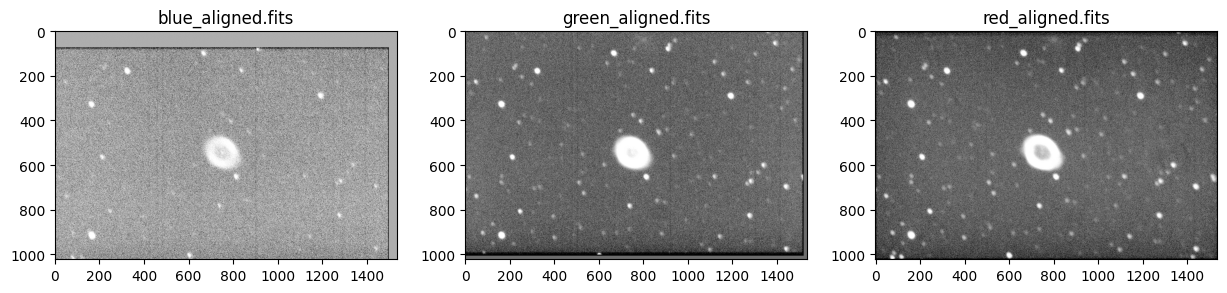

In [ ]:
# Make sure filters and paths match in length
filters = ['blue', 'green', 'red']  # or adjust to match your files
paths = []
for file in os.listdir("./m57/bgsub_stacked/"):
    if file.endswith(".fits"):
        paths.append(os.path.join("./m57/bgsub_stacked/", file))

stacked_images = {}
for i, fil in enumerate(filters):
    stacked_images[fil] = fits.getdata(paths[i])

fig, ax = plt.subplots(1, len(filters), figsize=(15, 5))
for i, fil in enumerate(filters):
    norm = simple_norm(stacked_images[fil], 'asinh', min_percent=5, max_percent=99)
    ax[i].imshow(stacked_images[fil], norm=norm, cmap='gray')
    ax[i].set_title(paths[i].split("/")[-1])
    



In [28]:
## First mask sources
from photutils.segmentation import detect_threshold, detect_sources
from photutils.utils import circular_footprint
from photutils.background import Background2D, MedianBackground
from astropy.stats import SigmaClip
from photutils.utils import calc_total_error

Get noise image (background and Poisson error)

In [ ]:
bkg_filters = {}
erimage_filters = {}

for i,image in enumerate(stacked_images.values()):
    
    sigma_clip = SigmaClip(sigma=3.0)
    threshold = detect_threshold(image, nsigma=2.0, sigma_clip=sigma_clip)
    segment_img = detect_sources(image, threshold, npixels=10)
    footprint = circular_footprint(radius=10)

    srcmask = segment_img.make_source_mask(footprint=footprint)
    #plt.imshow(srcmask)

    ## Get background image with sources masked
    
    sigma_clip = SigmaClip(sigma=3.0)
    bkg_estimator = MedianBackground()
    bkg = Background2D(image,(50,50),filter_size=(3,3),sigma_clip=sigma_clip,  ## this is the background and its noise
                    bkg_estimator=bkg_estimator,mask=srcmask)
    bkg_filters[filters[i]] = bkg
    
    erimage = calc_total_error(image-bkg.background, bkg.background_rms, 1.5)  ## this is the Poisson error added to background noise
    erimage_filters[filters[i]] = erimage

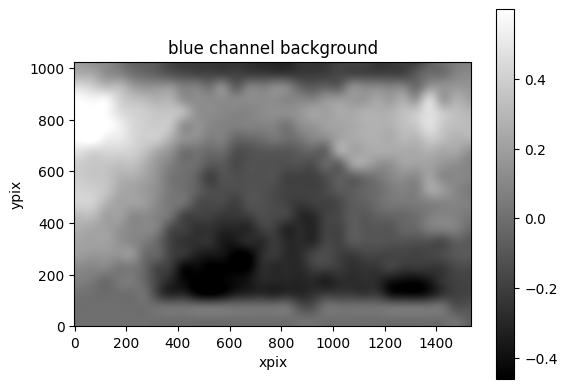

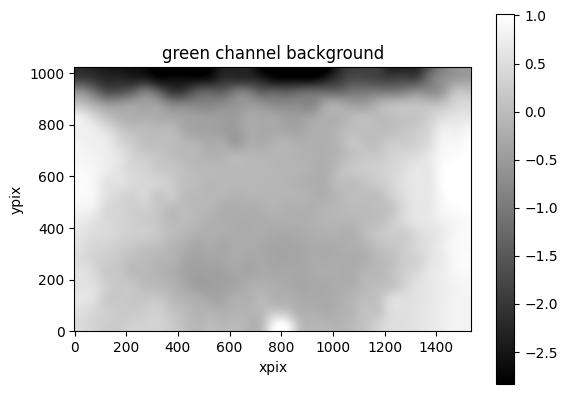

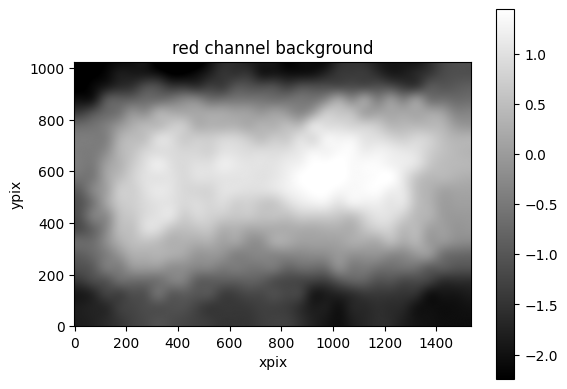

In [ ]:
## Background
lo,up = np.percentile(bkg.background,1),np.percentile(bkg.background,99)
plt.figure()
plt.imshow(bkg.background,cmap='gray',origin='lower',clim=(lo,up))
plt.colorbar()
plt.xlabel('xpix')
plt.ylabel('ypix')


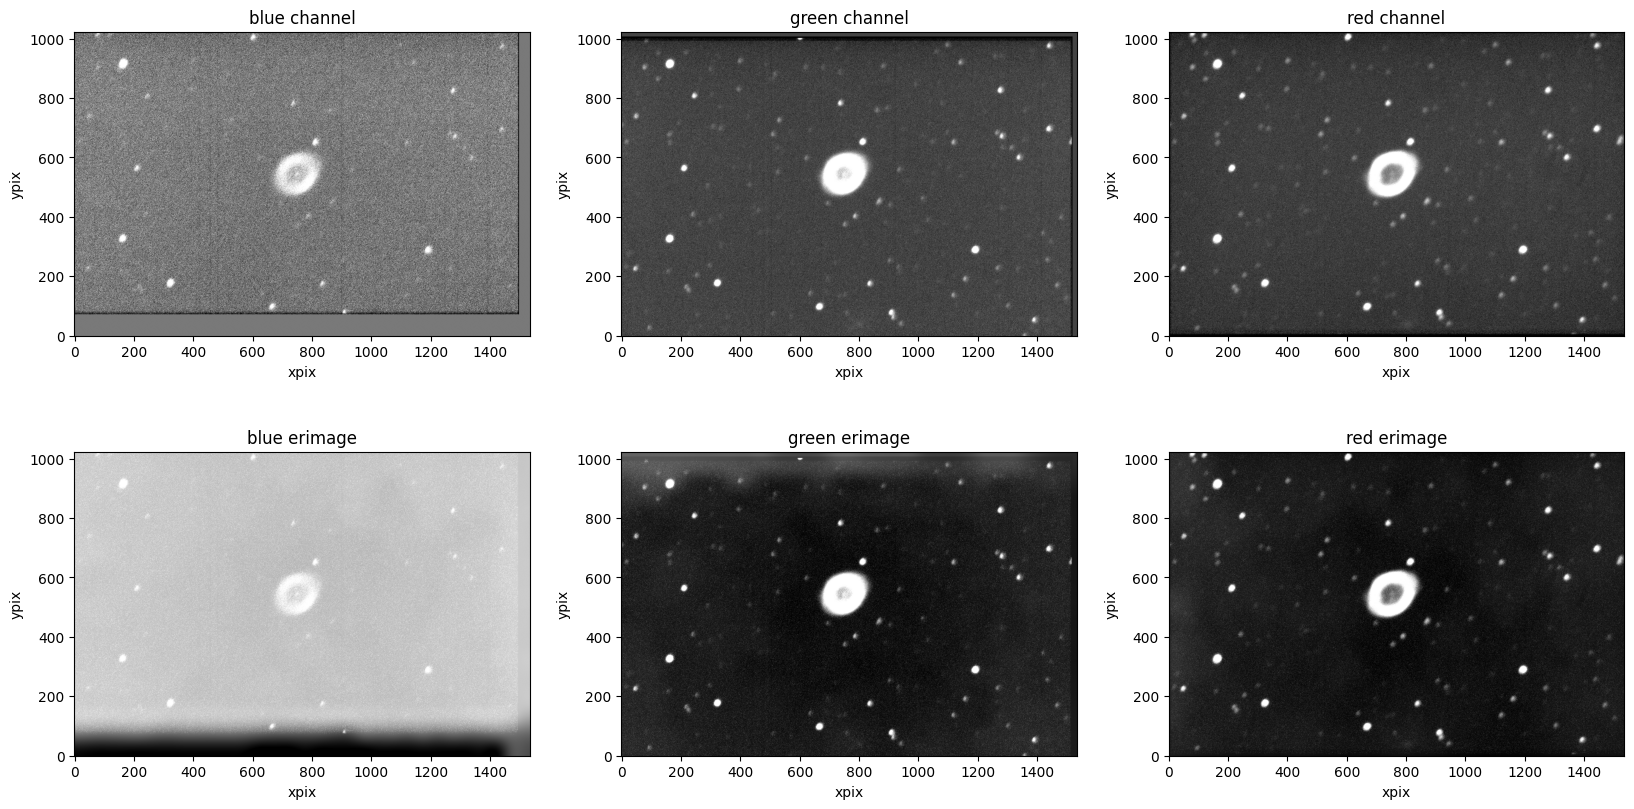

In [44]:
## Image and noise Plot
fig, ax = plt.subplots(2, 3, figsize=(20, 10))
for i,(image,erimage) in enumerate(zip(stacked_images.values(),erimage_filters.values())):
    lo,up = np.percentile(image,1),np.percentile(image,99)
    ax[0, i].imshow(image,cmap='gray',origin='lower',clim=(lo,up))
    ax[0, i].set_title(filters[i]+' channel')
    ax[0, i].set_xlabel('xpix')
    ax[0, i].set_ylabel('ypix')
    


for i,erimage in enumerate(erimage_filters.values()):
    lo,up = np.percentile(erimage,1),np.percentile(erimage,99)
    ax[1, i].imshow(erimage,cmap='gray',origin='lower',clim=(lo,up))
    ax[1, i].set_title(filters[i]+' erimage')
    ax[1, i].set_xlabel('xpix')
    ax[1, i].set_ylabel('ypix')

## Get central position of star with initial guess

blue channel centroid position: [948.18758284 359.50216071]
green channel centroid position: [941.99280696 359.28589176]
red channel centroid position: [958.69789089 362.86390496]


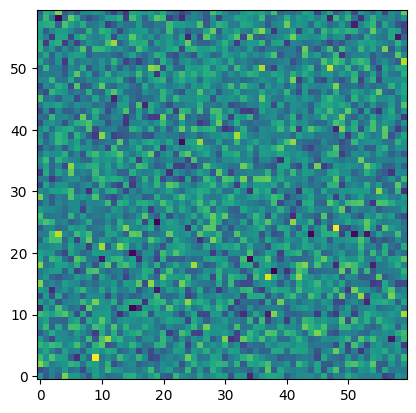

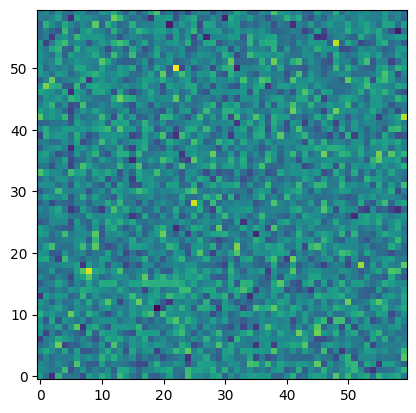

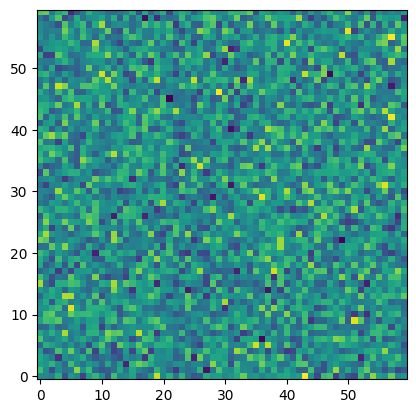

In [45]:
## Estimate position with an initial position guess of the star with centroid
pos_guess = [948,354]   ## initial guess (x,y) (CHANGE TO YOUR STAR POSITION!)
from photutils.centroids import centroid_com, centroid_2dg  #load centroid libraries
positions = {}
for fil in filters:
    image = stacked_images[fil]
    img = image[pos_guess[1]-30:pos_guess[1]+30, pos_guess[0]-30:pos_guess[0]+30] # select subportion of 60x60 image
    plt.figure()
    plt.imshow(img, origin='lower')
    position = centroid_com(img) + np.array(pos_guess) - np.array([30, 30])
    positions[fil] = position
    print(f'{fil} channel centroid position:', position)

Do aperture photometry

Photometry table for blue channel:
 id      xcenter      ...   aperture_sum_27   aperture_sum_err_27
--- ----------------- ... ------------------- -------------------
  1 948.1875828355614 ... -19.486557568340444  171.42780644253855
Errors: [ 16.98676462  22.94006235  28.74912556  34.49684882  40.19851013
  45.9027024   51.49960512  57.3010181   63.00589847  68.72206432
  74.42408693  80.02736738  85.73234894  91.39274199  97.02985953
 102.75169257 108.50190456 114.24933419 119.98582134 125.77915793
 131.52678999 137.21210667 142.94131063 148.65162272 154.36486454
 160.04469687 165.69555225 171.42780644]
Photometry table for green channel:
 id      xcenter      ...  aperture_sum_27   aperture_sum_err_27
--- ----------------- ... ------------------ -------------------
  1 941.9928069561953 ... -44.04424924380581   240.1418572747158
Errors: [ 24.0323166   32.14568746  40.17433896  48.23153713  56.07214483
  64.20181565  72.22395861  80.16991004  88.02010743  95.98519597
 103.99670134 112

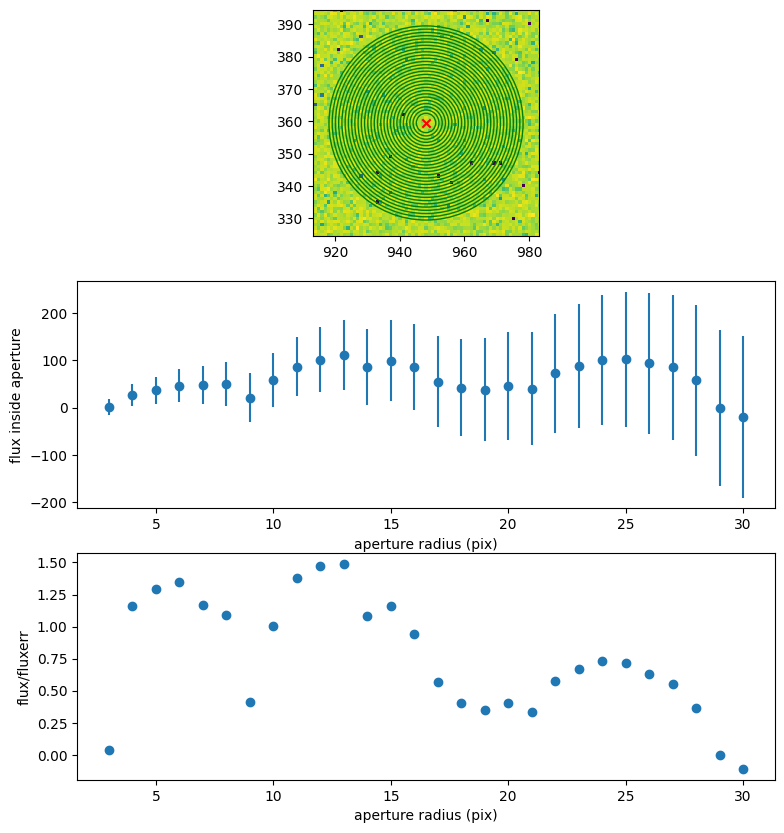

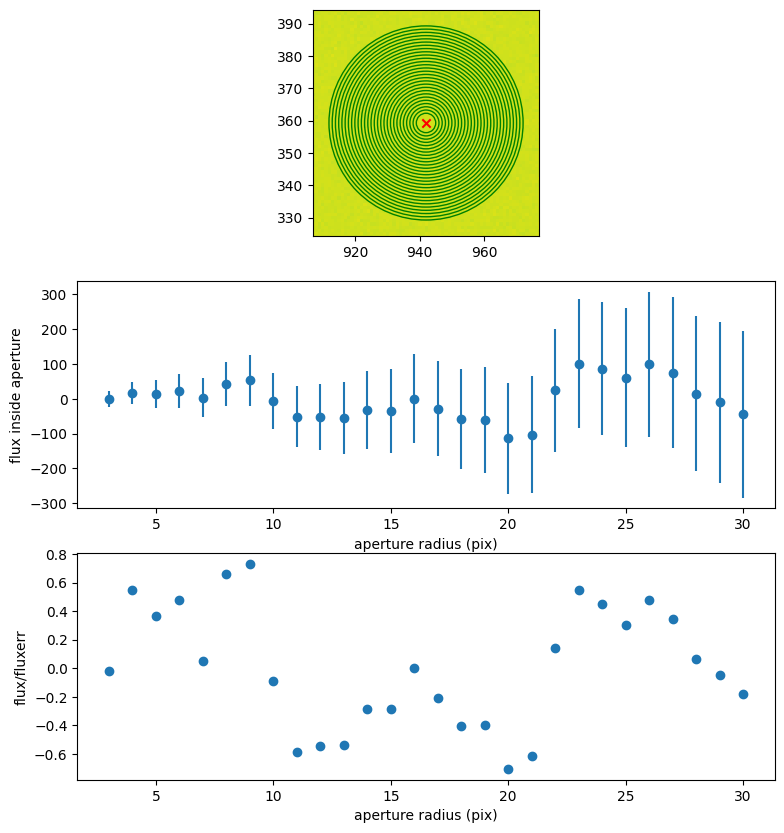

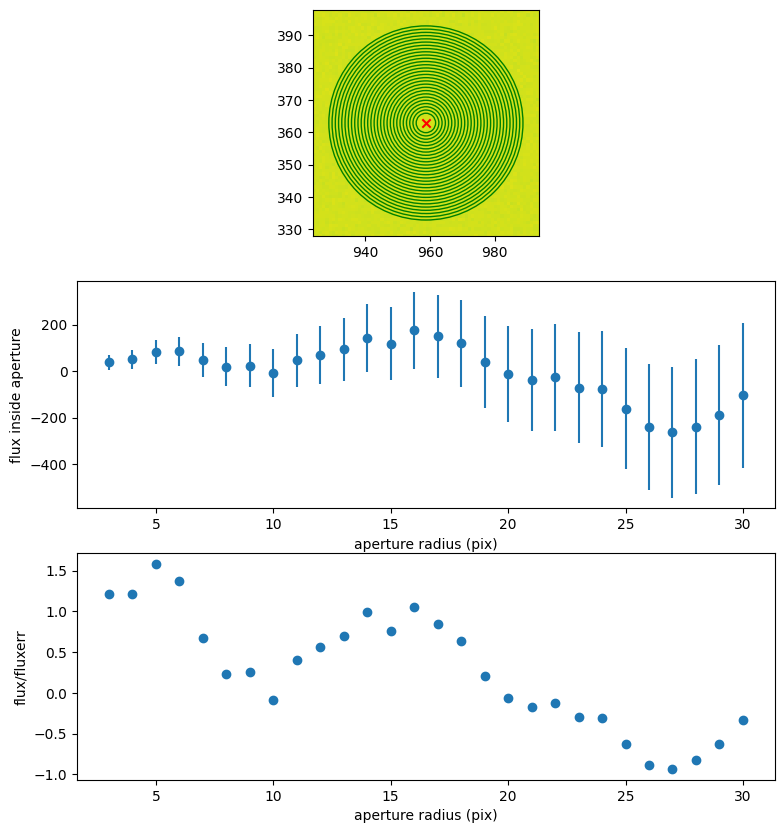

In [46]:
## Perform aperture photometry for every filter
from photutils.aperture import CircularAperture
radii = np.arange(3,31)  # radii (pix) of circular apertures
photometry_results = {}
for fil in filters:
    image = stacked_images[fil]
    bkg = bkg_filters[fil]
    erimage = erimage_filters[fil]
    position = positions[fil]
    aperture = [CircularAperture(position, r=r) for r in radii] # define circular apertures
    phot_table = aperture_photometry(image-bkg.background, aperture, error=erimage)
    y = np.asarray([phot_table['aperture_sum_'+str(i)] for i in np.arange(0, radii.size)], dtype=float)
    ery = np.asarray([phot_table['aperture_sum_err_'+str(i)] for i in np.arange(0, radii.size)], dtype=float)
    y = np.reshape(y, (len(y),))
    ery = np.reshape(ery, (len(ery),))
    photometry_results[fil] = {'phot_table': phot_table, 'y': y, 'ery': ery, 'position': position}
    print(f'Photometry table for {fil} channel:')
    print(phot_table)
    print('Errors:', ery)
    # Plot curve of growth and image with apertures
    from astropy.visualization import simple_norm
    fig, ax = plt.subplots(3, figsize=(9, 10))
    norm = simple_norm(image, 'log', percent=99.)
    ax[0].imshow(image, norm=norm, cmap='viridis', aspect=1, interpolation='nearest')
    ax[0].scatter(position[0], position[1], color='red', marker='x')
    for r in radii:
        circle = plt.Circle(position, r, color='green', fill=False)
        ax[0].add_artist(circle)
    ax[0].set_xlim([position[0]-35, position[0]+35])
    ax[0].set_ylim([position[1]-35, position[1]+35])
    # plot curve of growth
    ax[1].errorbar(radii, y, yerr=ery, fmt='o')
    ax[1].set_xlabel('aperture radius (pix)')
    ax[1].set_ylabel('flux inside aperture')
    # plot flux/fluxerr (S/N)
    ax[2].errorbar(radii, y/ery, fmt='o')
    ax[2].set_xlabel('aperture radius (pix)')
    ax[2].set_ylabel('flux/fluxerr')

In [47]:
## Final flux and error at a given radius for every filter
radius = 22 # (CHANGE TO YOUR RADIUS!)
for fil in filters:
    y = photometry_results[fil]['y']
    ery = photometry_results[fil]['ery']
    head = headers[fil] if 'headers' in locals() else None
    flux = y[np.round(radii) == np.round(radius)]
    error = ery[np.round(radii) == np.round(radius)]
    print(f"{fil} channel: Star flux (counts): {flux} +/- {error}")
    if head is not None and 'EXPTIME' in head:
        print(f"{fil} channel: Star flux (counts) per second: {flux/head['EXPTIME']} +/- {error/head['EXPTIME']}")

blue channel: Star flux (counts): [72.47369801] +/- [125.77915793]
green channel: Star flux (counts): [24.3989969] +/- [176.16993767]
red channel: Star flux (counts): [-27.35458491] +/- [229.02782968]
